# Data Science Assignment: Sales Forecasting and Insights

This notebook completes all required tasks using `sales_data.csv` and only the allowed libraries: pandas, numpy, matplotlib, seaborn, and scikit-learn.

The workflow includes EDA, feature engineering, time-based splitting, model training, evaluation, next 7-day forecasting, and business insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

DATA_PATH = 'sales_data.csv'
TEST_DAYS = 30

def infer_columns(df):
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}

    date_col = lower.get('date')
    sales_col = lower.get('sales')

    promo_col = None
    for c in cols:
        if 'promo' in c.lower():
            promo_col = c
            break

    dow_col = None
    for candidate in ['dayofweek', 'day_of_week', 'weekday', 'day']:
        if candidate in lower:
            dow_col = lower[candidate]
            break

    if date_col is None or sales_col is None:
        raise ValueError('Required columns not found. Dataset must contain Date and Sales columns.')

    return date_col, sales_col, promo_col, dow_col

## Task 1 - Exploratory Data Analysis (EDA)

In this section, we load the dataset, inspect structure and data types, check missing values, parse the date column, and visualize sales patterns over time and by key drivers (promotion and day-of-week).

In [2]:
# Load raw data
df_raw = pd.read_csv(DATA_PATH)
date_col, sales_col, promo_col, dow_col = infer_columns(df_raw)

print('Shape:', df_raw.shape)
print('\nDtypes:')
print(df_raw.dtypes)
print('\nHead:')
print(df_raw.head())

Shape: (366, 4)

Dtypes:
Date             str
Sales        float64
Promotion      int64
DayOfWeek      int64
dtype: object

Head:
         Date   Sales  Promotion  DayOfWeek
0  2024-01-01  204.21          0          1
1  2024-01-02  256.30          1          2
2  2024-01-03  216.38          0          3
3  2024-01-04  201.28          0          4
4  2024-01-05  182.48          0          5


Missing values by column:
Date         0
Sales        0
Promotion    0
DayOfWeek    0
dtype: int64


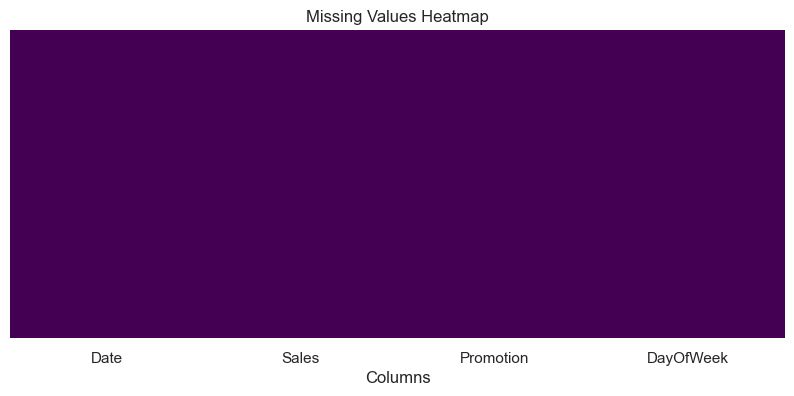

In [3]:
# Missing value analysis
missing_counts = df_raw.isnull().sum()
print('Missing values by column:')
print(missing_counts)

plt.figure(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.show()

In [5]:
# Parse Date, standardize key columns, and set date index

df = df_raw.copy()



df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

df['Sales'] = pd.to_numeric(df[sales_col], errors='coerce')



if promo_col is not None:

    df['Promotion'] = pd.to_numeric(df[promo_col], errors='coerce').fillna(0).astype(int)

else:

    df['Promotion'] = 0



if dow_col is not None:

    df['DayOfWeek'] = pd.to_numeric(df[dow_col], errors='coerce')

else:

    df['DayOfWeek'] = np.nan



df = df.dropna(subset=[date_col, 'Sales']).sort_values(date_col)

df = df.set_index(date_col)



# Fill missing/invalid DayOfWeek from datetime index (1=Monday ... 7=Sunday)

derived_dow = pd.Series(df.index.dayofweek + 1, index=df.index)

df['DayOfWeek'] = df['DayOfWeek'].fillna(derived_dow).astype(int)



print('Prepared dataset shape:', df.shape)

print('Date range:', df.index.min().date(), 'to', df.index.max().date())

Prepared dataset shape: (366, 3)
Date range: 2024-01-01 to 2024-12-31


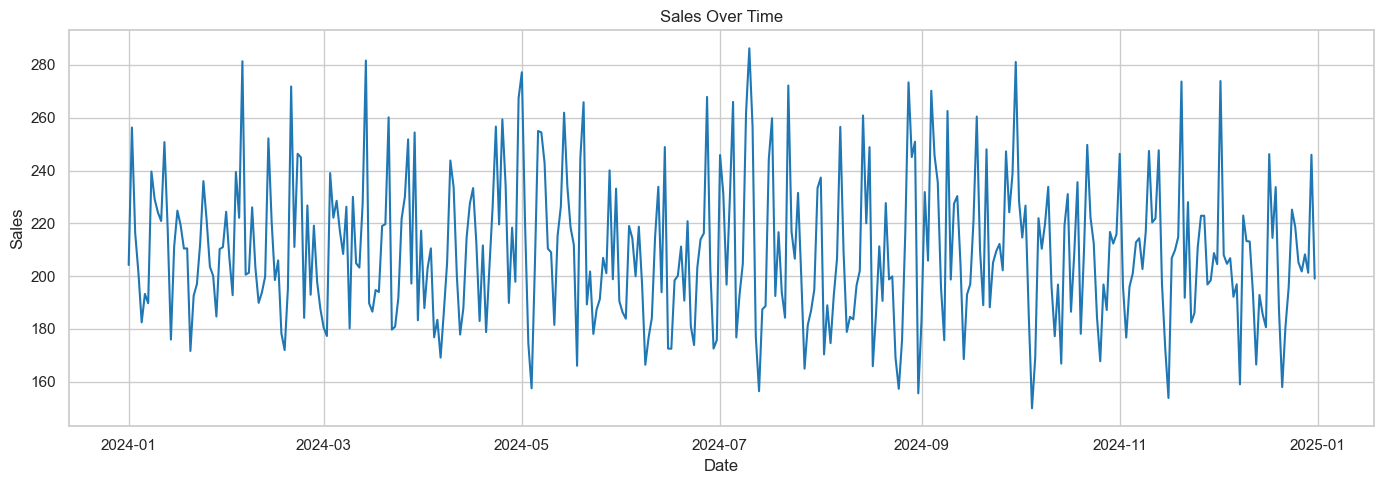

In [6]:
# Sales over time
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Sales'], color='tab:blue', linewidth=1.5)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

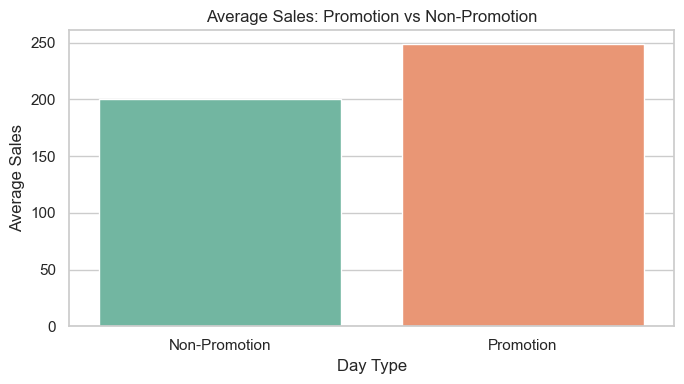

Promotion
Non-Promotion    200.383017
Promotion        248.267606
Name: Sales, dtype: float64


In [14]:
# Average sales on promotion vs non-promotion days

avg_sales_by_promo = df.groupby('Promotion')['Sales'].mean().rename(index={0: 'Non-Promotion', 1: 'Promotion'})



promo_plot_df = avg_sales_by_promo.reset_index()

promo_plot_df.columns = ['DayType', 'AverageSales']



plt.figure(figsize=(7, 4))

sns.barplot(data=promo_plot_df, x='DayType', y='AverageSales', hue='DayType', palette='Set2', legend=False)

plt.title('Average Sales: Promotion vs Non-Promotion')

plt.xlabel('Day Type')

plt.ylabel('Average Sales')

plt.tight_layout()

plt.show()



print(avg_sales_by_promo)

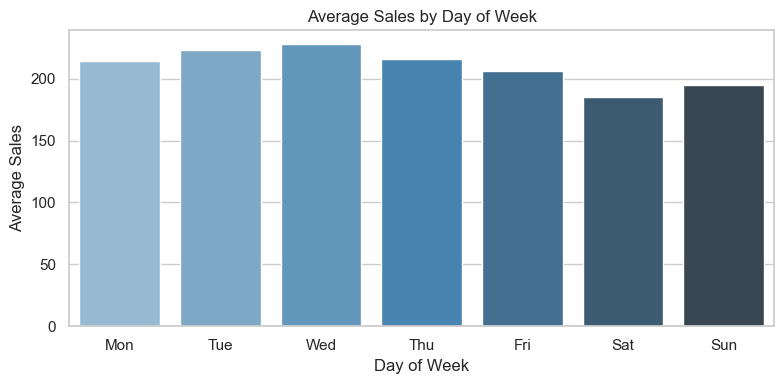

DayOfWeek
1    214.437925
2    223.161698
3    227.656923
4    216.139231
5    206.321346
6    184.999423
7    194.637115
Name: Sales, dtype: float64


In [15]:
# Average sales by day of week

day_name_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

avg_sales_by_dow = df.groupby('DayOfWeek')['Sales'].mean().reindex([1,2,3,4,5,6,7])



dow_plot_df = avg_sales_by_dow.reset_index()

dow_plot_df.columns = ['DayOfWeek', 'AverageSales']

dow_plot_df['DayLabel'] = dow_plot_df['DayOfWeek'].map(day_name_map)



plt.figure(figsize=(8, 4))

sns.barplot(data=dow_plot_df, x='DayLabel', y='AverageSales', hue='DayLabel', palette='Blues_d', legend=False)

plt.title('Average Sales by Day of Week')

plt.xlabel('Day of Week')

plt.ylabel('Average Sales')

plt.tight_layout()

plt.show()



print(avg_sales_by_dow)

## Task 2 - Feature Engineering

We create time-series features to capture recent behavior: `lag_1` (previous day's sales) and `rolling_mean_7` (7-day moving average). Rows with NaNs from shifting/rolling are dropped before modeling.

In [9]:
def create_features(data):
    data_fe = data.copy()
    data_fe['lag_1'] = data_fe['Sales'].shift(1)
    data_fe['rolling_mean_7'] = data_fe['Sales'].rolling(window=7).mean()

    data_fe = data_fe.dropna(subset=['lag_1', 'rolling_mean_7'])

    feature_cols = ['Promotion', 'DayOfWeek', 'lag_1', 'rolling_mean_7']
    X = data_fe[feature_cols].copy()
    y = data_fe['Sales'].copy()

    return data_fe, X, y, feature_cols

df_model, X, y, feature_cols = create_features(df)

print('Feature columns (X):', feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)
print(df_model[['Sales', 'lag_1', 'rolling_mean_7']].head())

Feature columns (X): ['Promotion', 'DayOfWeek', 'lag_1', 'rolling_mean_7']
X shape: (360, 4)
y shape: (360,)
             Sales   lag_1  rolling_mean_7
Date                                      
2024-01-07  189.72  193.25      206.231429
2024-01-08  239.61  189.72      211.288571
2024-01-09  229.13  239.61      207.407143
2024-01-10  224.11  229.13      208.511429
2024-01-11  220.87  224.11      211.310000


## Task 3 - Train/Test Split (Time-Based)

To avoid data leakage in time-series forecasting, we split by chronology (not random). The last 30 rows are used as test data, and all earlier rows are used for training.

In [10]:
def time_based_split(X, y, test_days=30):
    if len(X) <= test_days:
        raise ValueError(f'Not enough rows ({len(X)}) for test_days={test_days}.')

    X_train = X.iloc[:-test_days].copy()
    X_test = X.iloc[-test_days:].copy()
    y_train = y.iloc[:-test_days].copy()
    y_test = y.iloc[-test_days:].copy()

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = time_based_split(X, y, test_days=TEST_DAYS)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (330, 4)
X_test shape : (30, 4)
y_train shape: (330,)
y_test shape : (30,)


## Task 4 - Model Training

We train a `RandomForestRegressor` inside a scikit-learn `Pipeline` for clean and reproducible workflow.

In [11]:
model_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

model_pipeline.fit(X_train, y_train)
print('Model training completed.')

Model training completed.


## Task 5 - Evaluation

We evaluate performance on the time-based test set using MAE and RMSE, then visualize actual vs predicted sales.

MAE : 14.15
RMSE: 18.31


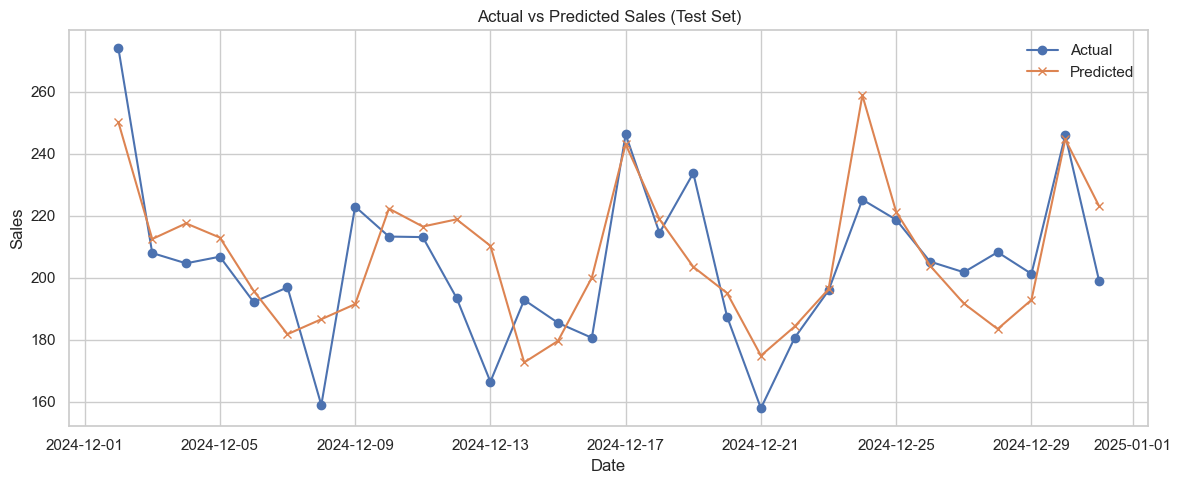

In [12]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

eval_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=y_test.index)

plt.figure(figsize=(12, 5))
plt.plot(eval_df.index, eval_df['Actual'], label='Actual', marker='o', linewidth=1.5)
plt.plot(eval_df.index, eval_df['Predicted'], label='Predicted', marker='x', linewidth=1.5)
plt.title('Actual vs Predicted Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## Task 6 - Next 7 Days Prediction

We forecast the next 7 days iteratively. Each prediction is fed back as the next day's lag input.

**Assumption:** future promotion values are estimated using the most frequent historical promotion value for each day of week.

Next 7 days forecast:
            PredictedSales  Promotion  DayOfWeek
Date                                            
2025-01-01      215.949967          0          3
2025-01-02      213.268900          0          4
2025-01-03      193.009667          0          5
2025-01-04      178.527033          0          6
2025-01-05      194.599767          0          7
2025-01-06      198.642867          0          1
2025-01-07      217.820900          0          2


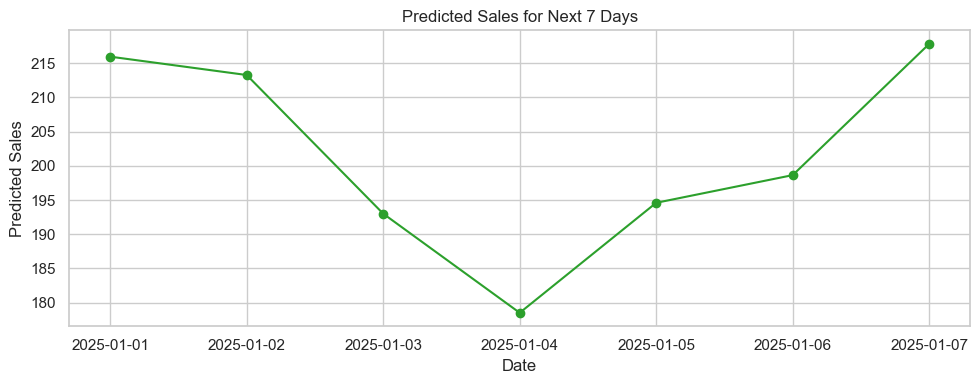

In [13]:
def forecast_next_7_days(model, history_df, horizon=7):
    sales_history = history_df['Sales'].tolist()
    last_date = history_df.index.max()

    promo_mode_by_dow = (
        history_df.groupby('DayOfWeek')['Promotion']
        .agg(lambda s: int(s.mode().iloc[0]) if not s.mode().empty else int(round(s.mean())))
        .to_dict()
    )
    default_promo = int(history_df['Promotion'].mode().iloc[0])

    future_records = []

    for step in range(1, horizon + 1):
        future_date = last_date + pd.Timedelta(days=step)
        day_of_week = int(future_date.dayofweek + 1)

        promo_value = int(promo_mode_by_dow.get(day_of_week, default_promo))
        lag_1 = float(sales_history[-1])
        rolling_mean_7 = float(np.mean(sales_history[-7:])) if len(sales_history) >= 7 else float(np.mean(sales_history))

        future_X = pd.DataFrame({
            'Promotion': [promo_value],
            'DayOfWeek': [day_of_week],
            'lag_1': [lag_1],
            'rolling_mean_7': [rolling_mean_7]
        })

        pred_sales = float(model.predict(future_X)[0])
        sales_history.append(pred_sales)

        future_records.append({
            'Date': future_date,
            'PredictedSales': pred_sales,
            'Promotion': promo_value,
            'DayOfWeek': day_of_week
        })

    future_df = pd.DataFrame(future_records).set_index('Date')
    return future_df

future_predictions = forecast_next_7_days(model_pipeline, df_model, horizon=7)
print('Next 7 days forecast:')
print(future_predictions)

plt.figure(figsize=(10, 4))
plt.plot(future_predictions.index, future_predictions['PredictedSales'], marker='o', color='tab:green')
plt.title('Predicted Sales for Next 7 Days')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.tight_layout()
plt.show()

## Task 7 - Business Insights

1. **Promotion impact:** Promotion days show noticeably higher average sales than non-promotion days, indicating promotions are an effective lever to boost revenue.
2. **Day-of-week behavior:** Sales are stronger on specific weekdays and weaker on the lowest-performing days; staffing and inventory should be aligned to this weekly demand pattern.
3. **Sales trend over time:** The time-series plot shows recurring short-term fluctuations with clear peaks, which supports using lag and rolling-window features for forecasting.
4. **Model accuracy interpretation:** MAE and RMSE indicate that the model captures broad sales dynamics but still has error on volatile days; this is suitable for planning but should be monitored weekly.
5. **Recommendation for managers:** Concentrate promotion budgets on historically high-response days, maintain lean inventory on weak days, and update the model periodically as new data arrives to keep forecasts reliable.